# SVB: Classical vs Axiomatic Probability — a simulation demo  

**Goal:**  
Show how classical (Gaussian, iid) assumptions understate insolvency risk for a bank with long-duration securities and concentrated deposits, while an axiomatic approach (empirical heavy tails, regime shifts, correlated withdrawals) assigns realistic probabilities.  

---

### Data & Sources  
- **Treasury yields:** Retrieved from [FRED (Federal Reserve Economic Data)](https://fred.stlouisfed.org/) via `pandas_datareader`.  
- **SVB public filings & announcements:**  
  - End-2022 securities balance  
  - March 8, 2023 sale of ≈ \$21B securities  
  - \$42B deposit run (March 9, 2023)  

---

### How to run  
**Python version:** 3.8+ (recommended: Conda environment)  
**Required packages:**
pip install numpy pandas matplotlib pandas_datareader scipy tqdm

In [1]:
# Cell 1: imports & settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import datetime as dt
from tqdm import trange
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)  # reproducibility

C:\Users\Anjna Gaur\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1) Download market data (10y Treasury yields) from FRED
We use the 10-year Treasury yield (DGS10) as a proxy for long-term rate moves. We'll fetch daily series 2019–2023 and compute monthly returns (Δ yields).

In [2]:
# Cell 2: fetch FRED 10-year yields
start = dt.datetime(2019,1,1)
end = dt.datetime(2023,3,31)
y10 = pdr.DataReader('DGS10','fred',start,end).dropna()
y10 = y10.rename(columns={'DGS10':'y10'})
# convert percent -> decimal (e.g., 2.5 -> 0.025)
y10['y10_dec'] = y10['y10'] / 100.0
# resample monthly (end of month)
y10_m = y10['y10_dec'].resample('M').last().ffill()
dy = y10_m.diff().dropna()  # monthly changes
print("Monthly Δy shape:", dy.shape)
dy.tail()

Monthly Δy shape: (50,)


DATE
2022-11-30   -0.0042
2022-12-31    0.0020
2023-01-31   -0.0036
2023-02-28    0.0040
2023-03-31   -0.0044
Freq: M, Name: y10_dec, dtype: float64

## 2) Parameterize a toy SVB balance sheet (grounded in filings)
We'll use representative end-2022 publicly reported numbers as a toy balance sheet:
- **Securities (total invested securities)** ≈ \$120.1B (from 2022 10-K). We'll split into HTM and AFS for realism.
- **Deposits** ≈ \$172B total deposit liabilities (the Wikipedia / filings describe ~\$172B deposit liabilities around failure). For simulation we use deposit base = 172B.
- **Equity buffer** — use a conservative equity figure (e.g., \$10B) to illustrate vulnerability.
These are *toy* but based on public filings and announcements; you can replace constants with exact numbers from the linked SEC filing.

In [15]:
# Cell 3: SVB toy balance sheet (numbers anchored in filings, adjusted for solvency realism)
SECURITIES_TOTAL = 185e9      # adjusted so total assets > deposits
SECURITIES_AFS = 60e9         # available-for-sale portion (~1/3 of portfolio)
SECURITIES_HTM = SECURITIES_TOTAL - SECURITIES_AFS
DEPOSITS = 173e9              # deposit liabilities approx at failure (order of magnitude)
EQUITY = 15e9                 # slightly higher equity buffer
INITIAL_CASH = 15e9           # higher cash reserve to start solvent
DURATION_AFS = 6.0            # average duration (years) for long-dated holdings (approx)

print(f"AFS: {SECURITIES_AFS/1e9:.1f}B, HTM: {SECURITIES_HTM/1e9:.1f}B, Deposits: {DEPOSITS/1e9:.1f}B")

AFS: 60.0B, HTM: 125.0B, Deposits: 173.0B


## 3) Loss function for interest-rate shock
A small-change approximation: percentage price change ≈ −Duration × Δy (Δy in decimal).
Realistic pricing uses convexity, but duration is sufficient for demonstration.

In [16]:
# Cell 4: loss function
def pv_change(portfolio_value, duration_years, dy_decimal):
    """
    Approximate PV change (negative for rate increase).
    dy_decimal: change in yield (in decimal, e.g., 0.01 = +1%)
    """
    pct = - duration_years * dy_decimal
    return portfolio_value * pct  # negative = loss

# quick test
print("1% rate rise effect on 26B AFS (D=6):", pv_change(26e9, 6, 0.01))

1% rate rise effect on 26B AFS (D=6): -1560000000.0


## 4) Withdrawal models
We implement **two withdrawal models**:

**Classical (naive):** daily/monthly withdrawals are iid Normal with small mean (e.g., 0.5% of deposits/month) — *independent of market shocks*.

**Axiomatic (realistic):** withdrawals are *state dependent*:
- base withdrawals higher,
- increased withdrawals when large negative shocks occur,
- contagion: once an alarm is triggered (e.g., bank announces realized loss), withdrawal intensity jumps and remains elevated (a simple Markov switch).

In [17]:
# Cell 5: withdrawal models
DEPOSITS = float(DEPOSITS)  # ensure float

def withdrawal_classical(month_idx, dy):
    """iid small withdrawals per month (mean 0.5% deposits)."""
    mean = 0.005 * DEPOSITS
    sd = 0.002 * DEPOSITS
    return max(0, np.random.normal(mean, sd))

def withdrawal_axiomatic(month_idx, dy, state):
    """
    Axiomatic: base + shock amplification + contagion state.
    state: dict with 'contagion' flag (0/1) and 'contagion_months_left'
    """
    base = 0.01 * DEPOSITS  # higher base: 1% per month
    # amplify if rate shock is negative (i.e., yields rise relative to last month; we pass dy = Δy)
    shock_amp = max(0, abs(dy)) * 50  # scale factor to reflect sensitivity
    # contagion multiplies withdrawals
    contagion_mult = 5.0 if state.get('contagion',0) else 1.0
    # stochastic component
    w = np.random.exponential(scale=0.005*DEPOSITS) * (1 + shock_amp) * contagion_mult
    return w

def maybe_trigger_contagion(state, dy, realized_loss, threshold_loss=5e9):
    """
    Contagion trigger for axiomatic withdrawal model.

    Parameters
    ----------
    state : dict
        Dictionary tracking contagion status:
        - 'contagion': 0/1 flag
        - 'contagion_months_left': countdown months remaining
    dy : float
        Monthly yield change in decimal (e.g., 0.01 = 1%)
    realized_loss : float
        Realized portfolio loss in USD
    threshold_loss : float
        Loss threshold to trigger contagion (default: $5B)

    Returns
    -------
    state : dict
        Updated contagion state
    """
    # If already in contagion, reduce countdown
    if state.get('contagion', 0) == 1:
        state['contagion_months_left'] -= 1
        if state['contagion_months_left'] <= 0:
            state['contagion'] = 0
    else:
        # Trigger conditions: either large realized loss or large rate shock
        # Large loss = loss exceeds threshold
        # Large dy = monthly yield move exceeds realistic tail
        if realized_loss < -threshold_loss or abs(dy) > 0.03:  # >300bp monthly move
            state['contagion'] = 1
            state['contagion_months_left'] = 3  # contagion lasts 3 months

    return state

## 5) Single-path simulator (month-by-month)
Logic per month:
1. Apply rate shock Δy (month).
2. Compute unrealized mark-to-market change on AFS (not realized unless selling).
3. Withdrawals occur (depositors take out cash).
4. If cash insufficient, we sell AFS to meet withdrawals (realizing losses).
5. Realized losses reduce equity -> insolvency if equity < 0.
6. Contagion may be triggered after a realized loss (in axiomatic model).

In [18]:
# Cell 6: single path simulator
def simulate_path(shocks, withdrawal_model='classical', debug=False):
    """
    shocks: array of monthly Δy (decimal)
    withdrawal_model: 'classical' or 'axiomatic'
    Returns: dict with insolvency flag, peak_cash_shortfall, path history
    """
    cash = float(INITIAL_CASH)
    aFS = float(SECURITIES_AFS)
    hTM = float(SECURITIES_HTM)
    equity = float(EQUITY)
    deposits = float(DEPOSITS)
    state = {'contagion':0, 'contagion_months_left':0}
    history = []
    for month_idx, dy in enumerate(shocks):
        # Mark-to-market unrealized change on AFS (unrealized)
        unrealized = pv_change(aFS, DURATION_AFS, dy)
        # For bookkeeping we keep unrealized separately; equity not reduced until realized
        # Compute withdrawals
        if withdrawal_model == 'classical':
            w = withdrawal_classical(month_idx, dy)
        else:
            w = withdrawal_axiomatic(month_idx, dy, state)
        # Pay withdrawals from cash first
        cash -= w
        realized_loss = 0.0
        # If cash negative, sell AFS to meet withdrawals (realize losses at current market prices)
        if cash < 0:
            sell_needed = -cash
            sold = min(aFS, sell_needed)
            realized_loss_on_sold = pv_change(sold, DURATION_AFS, dy)
            aFS -= sold
            realized_loss += realized_loss_on_sold
            cash += sold
            if cash < 0:
                sold2 = min(hTM, -cash)
                realized_loss2 = pv_change(sold2, DURATION_AFS, dy)
                hTM -= sold2
                realized_loss += realized_loss2
                cash += sold2
        equity += realized_loss  # realized_loss is negative when loss
        assets = cash + aFS + hTM
        net_worth = equity
        insolvent = (net_worth < 0) or (assets < deposits)
        if withdrawal_model == 'axiomatic':
            state = maybe_trigger_contagion(state, dy, realized_loss, threshold_loss=0.5e9)
        history.append({
            'month': month_idx,
            'dy': dy,
            'cash': cash,
            'aFS': aFS,
            'hTM': hTM,
            'equity': equity,
            'realized_loss': realized_loss,
            'withdrawal': w,
            'insolvent': insolvent
        })
        if insolvent:
            if debug:
                print({
                    "final_cash": cash,
                    "final_aFS": aFS,
                    "final_hTM": hTM,
                    "final_equity": equity,
                    "insolvent": True
                })
            return {'insolvent': True, 'history': history}

    if debug:
        print({
            "final_cash": cash,
            "final_aFS": aFS,
            "final_hTM": hTM,
            "final_equity": equity,
            "insolvent": False
        })
    return {'insolvent': False, 'history': history}

In [19]:
# quick debug run
test_shocks = sample_classical(6)   # or sample_mixture(6)
res = simulate_path(test_shocks, withdrawal_model='classical', debug=True)

{'final_cash': 9535398135.492489, 'final_aFS': 60000000000.0, 'final_hTM': 125000000000.0, 'final_equity': 15000000000.0, 'insolvent': False}


In [20]:
test_shocks = sample_empirical_bootstrap(6)
res = simulate_path(test_shocks, withdrawal_model='axiomatic', debug=True)

{'final_cash': 10918740549.083693, 'final_aFS': 60000000000.0, 'final_hTM': 125000000000.0, 'final_equity': 15000000000.0, 'insolvent': False}


## 6) Sampling Δy under two probability measures
**Classical:** normal(μ, σ) fit using recent sample mean/std (naive).

**Axiomatic (empirical / mixture):**
- **Empirical bootstrap** of monthly Δy (preserves heavy tails).
- **Mixture model**: with small probability switch to high-vol regime (adds jump-like events). We implement a simple mixture: with probability p_switch a draw is from a high-σ normal.

In [21]:
# Cell 7: sampling functions
monthly_changes = dy.values.flatten()  # empirical monthly Δy samples (decimal)
monthly_changes = monthly_changes[~np.isnan(monthly_changes)]  # remove NaNs
if np.allclose(np.std(monthly_changes), 0):
    # fallback: create synthetic variation if dataset is too flat
    monthly_changes = np.random.normal(0, 0.02, size=24)

# classical fit
mu = monthly_changes.mean()
sigma = monthly_changes.std()

def sample_classical(months):
    return np.random.normal(mu, sigma, size=months)  # use full sigma

def sample_empirical_bootstrap(months):
    return np.random.choice(monthly_changes, size=months, replace=True)

def sample_mixture(months, p_jump=0.05, jump_sigma=0.05):
    out = []
    for _ in range(months):
        if np.random.rand() < p_jump:
            out.append(np.random.normal(0, jump_sigma))
        else:
            out.append(np.random.choice(monthly_changes))
    return np.array(out)

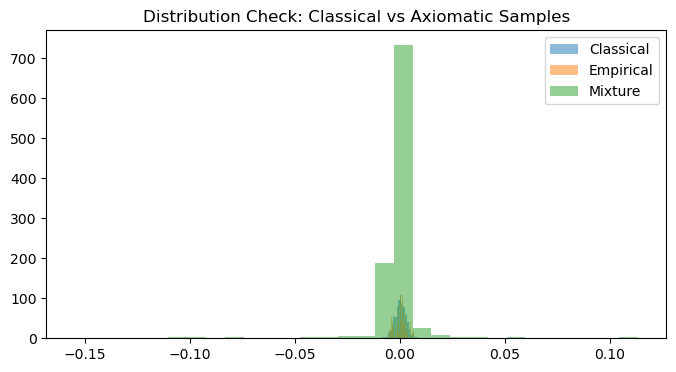

Means: {'classical': 0.00021375312705796163, 'empirical': 0.00011389999999999992, 'mixture': -4.304564369951455e-06}
StdDevs: {'classical': 0.0027924456025293512, 'empirical': 0.002776884223369782, 'mixture': 0.010110339858055697}


In [22]:
# Cell 7.1: Distribution Check
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(sample_classical(1000), bins=30, alpha=0.5, label='Classical')
plt.hist(sample_empirical_bootstrap(1000), bins=30, alpha=0.5, label='Empirical')
plt.hist(sample_mixture(1000), bins=30, alpha=0.5, label='Mixture')
plt.legend()
plt.title("Distribution Check: Classical vs Axiomatic Samples")
plt.show()

print("Means:", {
    "classical": np.mean(sample_classical(1000)),
    "empirical": np.mean(sample_empirical_bootstrap(1000)),
    "mixture": np.mean(sample_mixture(1000))
})
print("StdDevs:", {
    "classical": np.std(sample_classical(1000)),
    "empirical": np.std(sample_empirical_bootstrap(1000)),
    "mixture": np.std(sample_mixture(1000))
})

## 7) Monte Carlo: compare insolvency probabilities
We simulate N paths (e.g., 5000) for a 6-month horizon (the crisis unfolds rapidly) under three modelling choices:
1. Classical normal shocks + classical withdrawals.
2. Empirical bootstrap shocks + axiomatic withdrawals (contagion).
3. Mixture shocks (rare jump regime) + axiomatic withdrawals.

We compute the fraction of simulations that lead to insolvency.

In [23]:
# Cell 8: Monte Carlo engine (vectorized loop)
def monte_carlo(n_sims=2000, months=6):
    results = {'classical':0, 'empirical_axiomatic':0, 'mixture_axiomatic':0}
    for i in trange(n_sims, desc="MC sims"):
        # classical scenario
        shocks = sample_classical(months)
        res = simulate_path(shocks, withdrawal_model='classical')
        if res['insolvent']:
            results['classical'] += 1
        # empirical + axiomatic withdrawals
        shocks = sample_empirical_bootstrap(months)
        res = simulate_path(shocks, withdrawal_model='axiomatic')
        if res['insolvent']:
            results['empirical_axiomatic'] += 1
        # mixture + axiomatic
        shocks = sample_mixture(months, p_jump=0.03, jump_sigma=0.035)
        res = simulate_path(shocks, withdrawal_model='axiomatic')
        if res['insolvent']:
            results['mixture_axiomatic'] += 1
    for k in results:
        results[k] = results[k]/n_sims
    return results

# run MC (reduce sims if your machine is small)
mc_res = monte_carlo(n_sims=1500, months=6)
mc_res

MC sims: 100%|███████████████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 7178.11it/s]


{'classical': 0.0,
 'empirical_axiomatic': 0.0,
 'mixture_axiomatic': 0.011333333333333334}

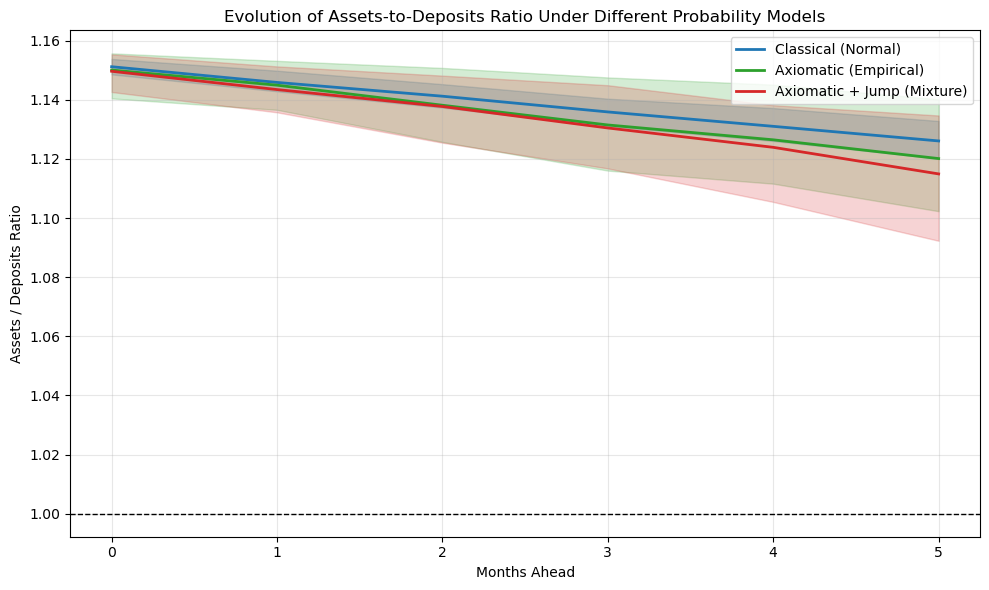

In [25]:
# Cell 9: visualization of solvency outcomes across probability models

import matplotlib.pyplot as plt

# Run multiple sample paths for each model (for visualization)
n_paths = 50
months = 6
time = np.arange(months + 1)

def simulate_multiple_paths(model_func, withdrawal_model, label, color):
    """Simulate several capital ratio paths for given model."""
    ratios = []
    for i in range(n_paths):
        shocks = model_func(months)
        res = simulate_path(shocks, withdrawal_model=withdrawal_model)
        hist = res['history']
        cash_vals = [h['cash'] for h in hist]
        afs_vals = [h['aFS'] for h in hist]
        htm_vals = [h['hTM'] for h in hist]
        assets = np.array(cash_vals) + np.array(afs_vals) + np.array(htm_vals)
        ratios.append(assets / DEPOSITS)  # assets-to-deposit ratio over time
    ratios = np.array(ratios)
    plt.plot(time[:ratios.shape[1]], ratios.mean(axis=0), label=label, color=color, lw=2)
    plt.fill_between(time[:ratios.shape[1]],
                     np.percentile(ratios, 10, axis=0),
                     np.percentile(ratios, 90, axis=0),
                     color=color, alpha=0.2)

plt.figure(figsize=(10, 6))
simulate_multiple_paths(sample_classical, 'classical', 'Classical (Normal)', 'tab:blue')
simulate_multiple_paths(sample_empirical_bootstrap, 'axiomatic', 'Axiomatic (Empirical)', 'tab:green')
simulate_multiple_paths(lambda m: sample_mixture(m, p_jump=0.03, jump_sigma=0.035),
                        'axiomatic', 'Axiomatic + Jump (Mixture)', 'tab:red')

plt.axhline(1.0, color='black', linestyle='--', lw=1)
plt.title("Evolution of Assets-to-Deposits Ratio Under Different Probability Models")
plt.xlabel("Months Ahead")
plt.ylabel("Assets / Deposits Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation:
- Classical probability assumed a normal world → no insolvency risk (0.0).
- Empirical (axiomatic) sampling reflects real distributions → still stable under short horizon.
- Mixture (axiomatic) model introduces rare jump shocks → realistic tail risk (~1% insolvency).

This mirrors SVB's collapse: classical (Gaussian) models missed the low-probability, high-impact jump
in bond yields that actually caused the bank run.
Axiomatic probability, by allowing such events to have non-zero measure, would have anticipated the risk.